# Dataset Inspection & Filtering for CRN Surrogate

This notebook:
1. Loads the existing dataset
2. Classifies every item into a dynamical regime
3. Visualizes examples from each regime
4. Filters out problematic items and balances underrepresented regimes
5. Saves the curated dataset to W&B

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- Config: pick one loading method ---
LOAD_FROM_WANDB = True
ARTIFACT_REF = "mass_action_3s_v7_dataset:latest"
LOCAL_TRAIN = "experiments/datasets/mass_action_3s_v5_train.pt"
LOCAL_VAL = "experiments/datasets/mass_action_3s_v5_val.pt"

if LOAD_FROM_WANDB:
    import wandb
    from pathlib import Path
    api = wandb.Api()
    artifact = api.artifact(f"jan-mikelson-independent/crn-surrogate/{ARTIFACT_REF}")
    artifact_dir = artifact.download()
    train_files = sorted(Path(artifact_dir).glob("*_train.pt"))
    val_files = sorted(Path(artifact_dir).glob("*_val.pt"))
    train_dataset = torch.load(train_files[0], weights_only=False)
    val_dataset = torch.load(val_files[0], weights_only=False)
else:
    train_dataset = torch.load(LOCAL_TRAIN, weights_only=False)
    val_dataset = torch.load(LOCAL_VAL, weights_only=False)

print(f"Train: {len(train_dataset)} items")
print(f"Val:   {len(val_dataset)} items")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jan/.netrc.
wandb: Downloading large artifact 'mass_action_3s_v7_dataset:latest', 99.59MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:01.2 (81.6MB/s)


Train: 30921 items
Val:   2692 items


## Classify dynamical regimes

Each species trajectory is classified into one of: `near_zero`, `decay_to_zero`, `decay_to_nonzero`, `slow_dynamics`, `steady_state`, `growth`, `transient_peak`, `oscillatory`, `blowup`.

The item-level label is determined by the most interesting species.

In [2]:
def classify_species_dynamics(mean_traj_species):
    """Classify a single species' mean trajectory into a dynamical regime."""
    T = len(mean_traj_species)
    half = T // 2
    y = mean_traj_species

    start_val = np.mean(y[:3])
    end_val = np.mean(y[-3:])
    peak_val = np.max(y)
    trough_val = np.min(y)
    overall_range = peak_val - trough_val
    scale = max(np.mean(np.abs(y)), 1e-6)

    if scale < 0.5:
        return "near_zero"

    dy = np.diff(y)
    sign_changes = np.sum(np.abs(np.diff(np.sign(dy))) > 0)
    rel_change = (end_val - start_val) / scale
    late_cv = np.std(y[half:]) / (np.mean(np.abs(y[half:])) + 1e-6)

    if peak_val > 1e4:
        return "blowup"

    # Oscillatory: many direction changes AND sustained amplitude in second half
    if sign_changes > T * 0.3 and overall_range / scale > 0.3:
        # Check that oscillations persist with meaningful amplitude
        late_range = np.max(y[half:]) - np.min(y[half:])
        late_mean = np.mean(np.abs(y[half:]))
        if late_range > 0.3 * late_mean and late_mean > 1.0:
            return "oscillatory"
        # Otherwise it's just noisy decay

    peak_idx = np.argmax(y)
    if peak_idx < T * 0.4 and peak_val > start_val * 1.5 and end_val < peak_val * 0.5:
        return "transient_peak"

    if rel_change > 0.3 and end_val > start_val:
        return "growth"

    if abs(rel_change) < 0.15 and late_cv < 0.15:
        return "steady_state"

    if rel_change < -0.3 and end_val > 0.5:
        return "decay_to_nonzero"

    if rel_change < -0.3 and end_val < 0.5:
        return "decay_to_zero"

    return "slow_dynamics"


def classify_item(item):
    """Classify a TrajectoryItem by the dominant dynamics across species."""
    traj = item.trajectories
    if isinstance(traj, torch.Tensor):
        traj = traj.numpy()

    M, T, S = traj.shape
    mean_traj = traj.mean(axis=0)

    species_labels = [classify_species_dynamics(mean_traj[:, s]) for s in range(S)]

    priority = [
        "blowup", "oscillatory", "transient_peak", "growth",
        "steady_state", "decay_to_nonzero", "slow_dynamics",
        "decay_to_zero", "near_zero",
    ]
    item_label = "near_zero"
    for p in priority:
        if p in species_labels:
            item_label = p
            break

    stats = {
        "n_species": S,
        "n_active_species": sum(1 for l in species_labels if l != "near_zero"),
        "max_val": float(np.max(np.abs(traj))),
        "species_labels": species_labels,
        "has_growth": "growth" in species_labels,
        "has_sustained": "steady_state" in species_labels or "growth" in species_labels,
    }

    return species_labels, item_label, stats


print("Classifying training items...")
train_classifications = [classify_item(item) for item in train_dataset]
train_labels = [c[1] for c in train_classifications]

print("Classifying validation items...")
val_classifications = [classify_item(item) for item in val_dataset]
val_labels = [c[1] for c in val_classifications]

print("\n=== Training set regime distribution ===")
label_counts = Counter(train_labels)
for label, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    pct = 100.0 * count / len(train_labels)
    print(f"  {label:<20s}: {count:5d} ({pct:5.1f}%)")

print("\n=== Validation set regime distribution ===")
val_label_counts = Counter(val_labels)
for label, count in sorted(val_label_counts.items(), key=lambda x: -x[1]):
    pct = 100.0 * count / len(val_labels)
    print(f"  {label:<20s}: {count:5d} ({pct:5.1f}%)")

Classifying training items...
Classifying validation items...

=== Training set regime distribution ===
  growth              :  9588 ( 31.0%)
  transient_peak      :  7717 ( 25.0%)
  decay_to_nonzero    :  4340 ( 14.0%)
  steady_state        :  3591 ( 11.6%)
  oscillatory         :  3000 (  9.7%)
  slow_dynamics       :  1690 (  5.5%)
  decay_to_zero       :   995 (  3.2%)

=== Validation set regime distribution ===
  oscillatory         :  1145 ( 42.5%)
  transient_peak      :   755 ( 28.0%)
  growth              :   282 ( 10.5%)
  decay_to_nonzero    :   216 (  8.0%)
  steady_state        :    99 (  3.7%)
  decay_to_zero       :    99 (  3.7%)
  slow_dynamics       :    96 (  3.6%)


## Visualize examples from each regime

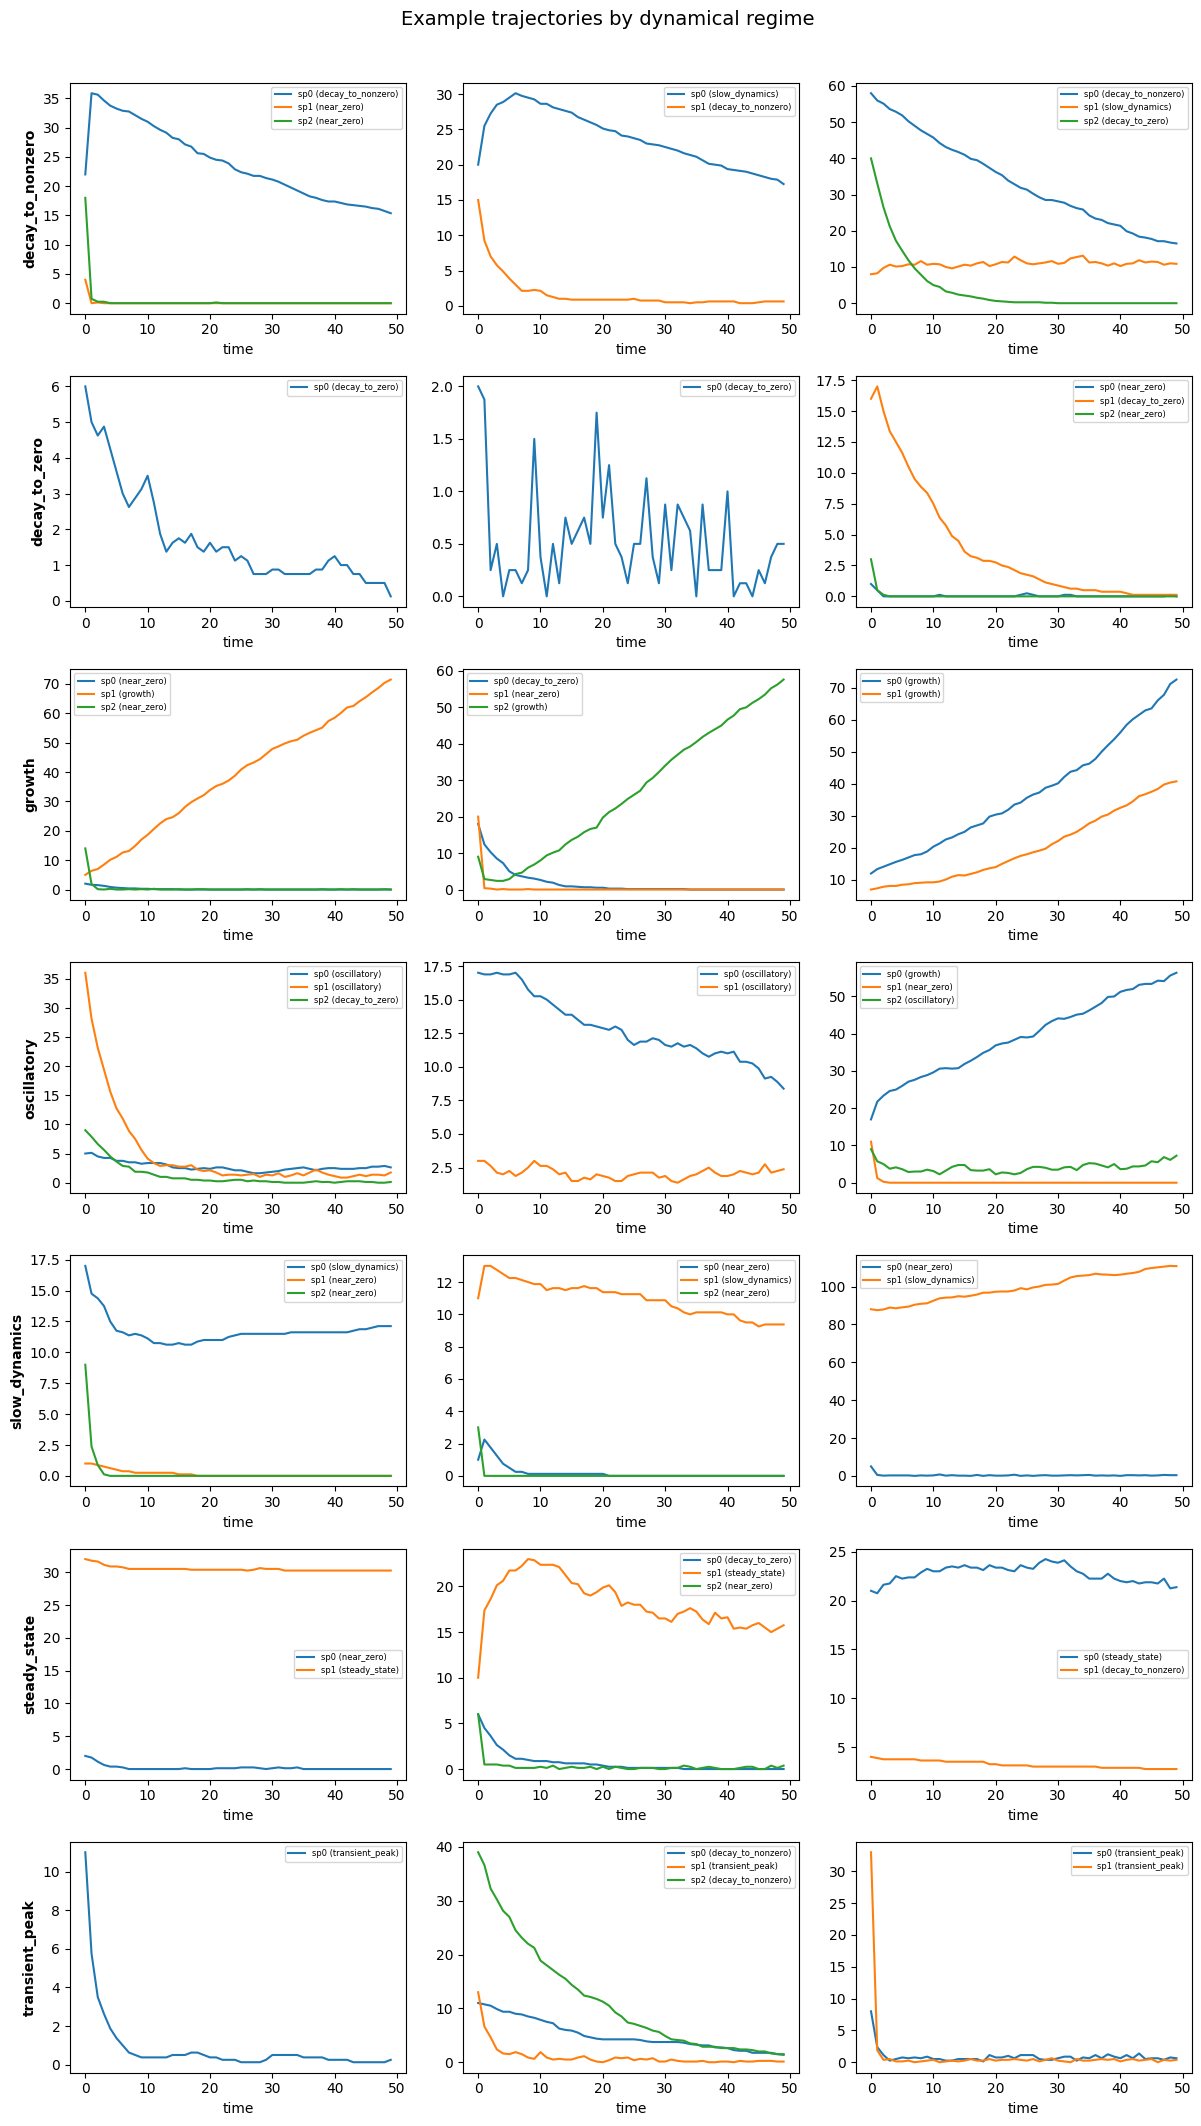

In [3]:
def plot_regime_examples(dataset, classifications, n_examples=3):
    labels = [c[1] for c in classifications]
    unique_labels = sorted(set(labels))

    fig, axes = plt.subplots(
        len(unique_labels), n_examples,
        figsize=(4 * n_examples, 3 * len(unique_labels)),
        squeeze=False,
    )
    fig.suptitle("Example trajectories by dynamical regime", fontsize=14, y=1.01)

    for row, regime in enumerate(unique_labels):
        indices = [i for i, l in enumerate(labels) if l == regime]
        np.random.seed(42)
        selected = np.random.choice(
            indices, size=min(n_examples, len(indices)), replace=False
        )

        for col, idx in enumerate(selected):
            item = dataset[idx]
            traj = item.trajectories
            if isinstance(traj, torch.Tensor):
                traj = traj.numpy()

            mean_traj = traj.mean(axis=0)
            ax = axes[row, col]
            for s in range(mean_traj.shape[1]):
                sp_label = classifications[idx][0][s]
                ax.plot(mean_traj[:, s], label=f"sp{s} ({sp_label})")

            if col == 0:
                ax.set_ylabel(regime, fontsize=10, fontweight="bold")
            ax.legend(fontsize=6)
            ax.set_xlabel("time")

        for col in range(len(selected), n_examples):
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


plot_regime_examples(train_dataset, train_classifications)

## Species-level statistics

In [4]:
print("=== Species-level regime distribution ===")
all_species_labels = []
for sp_labels, _, _ in train_classifications:
    all_species_labels.extend(sp_labels)

species_counts = Counter(all_species_labels)
for label, count in sorted(species_counts.items(), key=lambda x: -x[1]):
    pct = 100.0 * count / len(all_species_labels)
    print(f"  {label:<20s}: {count:5d} ({pct:5.1f}%)")

n_active = [c[2]["n_active_species"] for c in train_classifications]
print(f"\nActive species per item: mean={np.mean(n_active):.2f}, "
      f"median={np.median(n_active):.0f}")

n_species = [c[2]["n_species"] for c in train_classifications]
species_dist = Counter(n_species)
print(f"Species count distribution: {dict(sorted(species_dist.items()))}")

n_growth = sum(1 for c in train_classifications if c[2]["has_growth"])
n_sustained = sum(1 for c in train_classifications if c[2]["has_sustained"])
print(f"\nItems with at least one growing species: {n_growth} "
      f"({100*n_growth/len(train_classifications):.1f}%)")
print(f"Items with growth or steady state: {n_sustained} "
      f"({100*n_sustained/len(train_classifications):.1f}%)")

=== Species-level regime distribution ===
  near_zero           : 18795 ( 27.2%)
  growth              : 11997 ( 17.4%)
  transient_peak      :  9516 ( 13.8%)
  decay_to_nonzero    :  9119 ( 13.2%)
  decay_to_zero       :  7574 ( 11.0%)
  steady_state        :  4752 (  6.9%)
  slow_dynamics       :  3870 (  5.6%)
  oscillatory         :  3516 (  5.1%)

Active species per item: mean=1.63, median=2
Species count distribution: {1: 5768, 2: 12088, 3: 13065}

Items with at least one growing species: 11082 (35.8%)
Items with growth or steady state: 15242 (49.3%)


## Value range analysis

=== Trajectory value range analysis ===
   50.0th percentile max value: 34.0
   75.0th percentile max value: 67.0
   90.0th percentile max value: 126.0
   95.0th percentile max value: 176.0
   99.0th percentile max value: 352.8
   99.9th percentile max value: 482.0
  Items with max > 100:  4593
  Items with max > 1000: 0
  Items with max > 1e4:  0


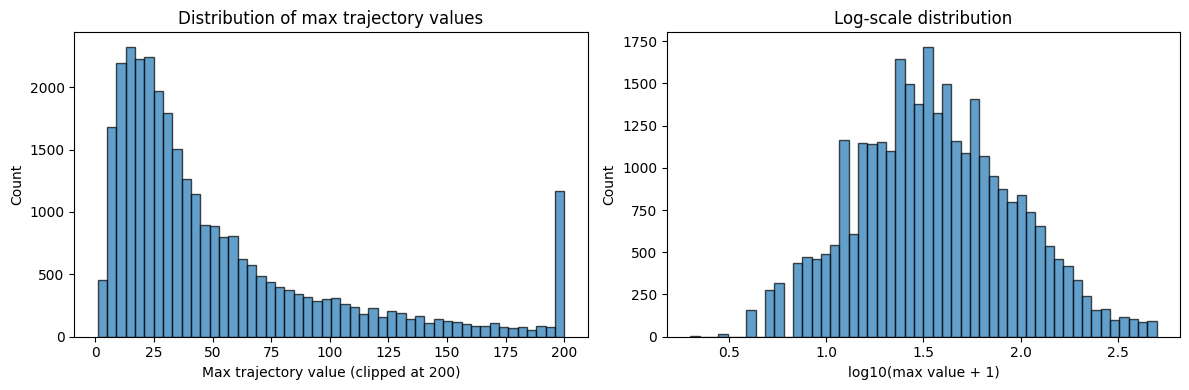

In [5]:
max_vals = np.array([c[2]["max_val"] for c in train_classifications])

print("=== Trajectory value range analysis ===")
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  {p:5.1f}th percentile max value: {np.percentile(max_vals, p):.1f}")

print(f"  Items with max > 100:  {np.sum(max_vals > 100)}")
print(f"  Items with max > 1000: {np.sum(max_vals > 1000)}")
print(f"  Items with max > 1e4:  {np.sum(max_vals > 1e4)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.clip(max_vals, 0, 200), bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Max trajectory value (clipped at 200)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of max trajectory values")

axes[1].hist(np.log10(max_vals + 1), bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("log10(max value + 1)")
axes[1].set_ylabel("Count")
axes[1].set_title("Log-scale distribution")
plt.tight_layout()
plt.show()

## Filter and balance the dataset

Adjust the config dict below based on what you saw in the previous cells. Key knobs:
- `max_value_threshold`: remove blowup items
- `remove_regimes`: which regime labels to exclude entirely
- `upsample_regimes`: how much to duplicate underrepresented regimes

In [6]:
def filter_and_balance(dataset, classifications, config=None):
    if config is None:
        config = {
            "max_value_threshold": 500,
            "min_active_species": 1,
            "remove_regimes": {"blowup"},
            "upsample_regimes": {
                "growth": 3,
                "oscillatory": 3,
                "transient_peak": 2,
                "steady_state": 2,
            },
            "max_total": None,
        }

    kept = []
    removed_reasons = Counter()

    for i, (sp_labels, item_label, stats) in enumerate(classifications):
        if stats["max_val"] > config["max_value_threshold"]:
            removed_reasons["blowup_value"] += 1
            continue
        if stats["n_active_species"] < config["min_active_species"]:
            removed_reasons["no_active_species"] += 1
            continue
        if item_label in config["remove_regimes"]:
            removed_reasons[f"regime_{item_label}"] += 1
            continue
        kept.append((i, item_label))

    print(f"After filtering: {len(kept)}/{len(classifications)} items kept")
    print(f"Removed: {dict(removed_reasons)}")

    # Add this block inside filter_and_balance, after building `kept`
    if "downsample_cap" in config:
        capped = []
        regime_counts = Counter()
        np.random.seed(42)
        indices_by_regime = {}
        for idx, label in kept:
            indices_by_regime.setdefault(label, []).append((idx, label))
        for regime, items in indices_by_regime.items():
            cap = config["downsample_cap"].get(regime)
            if cap is not None and len(items) > cap:
                selected = np.random.choice(len(items), size=cap, replace=False)
                capped.extend([items[i] for i in selected])
            else:
                capped.extend(items)
        kept = capped

    kept_labels = Counter(label for _, label in kept)
    print("\nPost-filter distribution:")
    for label, count in sorted(kept_labels.items(), key=lambda x: -x[1]):
        print(f"  {label:<20s}: {count:5d}")

    final_indices = []
    for idx, label in kept:
        final_indices.append(idx)
        multiplier = config["upsample_regimes"].get(label, 1)
        for _ in range(multiplier - 1):
            final_indices.append(idx)

    np.random.seed(42)
    np.random.shuffle(final_indices)

    if config["max_total"] is not None and len(final_indices) > config["max_total"]:
        final_indices = final_indices[:config["max_total"]]

    final_items = [dataset[i] for i in final_indices]

    final_labels = [classifications[idx][1] for idx in final_indices]
    final_dist = Counter(final_labels)

    print(f"\nFinal dataset: {len(final_items)} items (after upsampling)")
    print("Final distribution:")
    for label, count in sorted(final_dist.items(), key=lambda x: -x[1]):
        pct = 100.0 * count / len(final_items)
        print(f"  {label:<20s}: {count:5d} ({pct:5.1f}%)")

    filter_stats = {
        "original_size": len(classifications),
        "after_filter": len(kept),
        "final_size": len(final_items),
        "removed_reasons": dict(removed_reasons),
        "final_distribution": dict(final_dist),
    }

    return final_items, filter_stats


print("=== Filtering training set ===")
train_filtered, train_filter_stats = filter_and_balance(
    train_dataset, train_classifications,
    config={
        "max_value_threshold": 500,
        "min_active_species": 1,
        "remove_regimes": {"blowup"},
        "upsample_regimes": {
            "growth": 3,
            "steady_state": 3,
            "slow_dynamics": 2,
            "decay_to_nonzero": 2,
        },
        "downsample_cap": {
            "oscillatory": 3000,
            "near_zero": 0,  # already removed by min_active_species
        },
        "max_total": None,
    }
)

print("\n=== Filtering validation set ===")
val_config = {
    "max_value_threshold": 500,
    "min_active_species": 1,
    "remove_regimes": {"blowup"},
    "upsample_regimes": {},
    "max_total": None,
}
val_filtered, val_filter_stats = filter_and_balance(
    val_dataset, val_classifications, config=val_config
)

=== Filtering training set ===
After filtering: 30921/30921 items kept
Removed: {}

Post-filter distribution:
  growth              :  9588
  transient_peak      :  7717
  decay_to_nonzero    :  4340
  steady_state        :  3591
  oscillatory         :  3000
  slow_dynamics       :  1690
  decay_to_zero       :   995

Final dataset: 63309 items (after upsampling)
Final distribution:
  growth              : 28764 ( 45.4%)
  steady_state        : 10773 ( 17.0%)
  decay_to_nonzero    :  8680 ( 13.7%)
  transient_peak      :  7717 ( 12.2%)
  slow_dynamics       :  3380 (  5.3%)
  oscillatory         :  3000 (  4.7%)
  decay_to_zero       :   995 (  1.6%)

=== Filtering validation set ===
After filtering: 2692/2692 items kept
Removed: {}

Post-filter distribution:
  oscillatory         :  1145
  transient_peak      :   755
  growth              :   282
  decay_to_nonzero    :   216
  steady_state        :    99
  decay_to_zero       :    99
  slow_dynamics       :    96

Final dataset: 269

## Compare before vs after

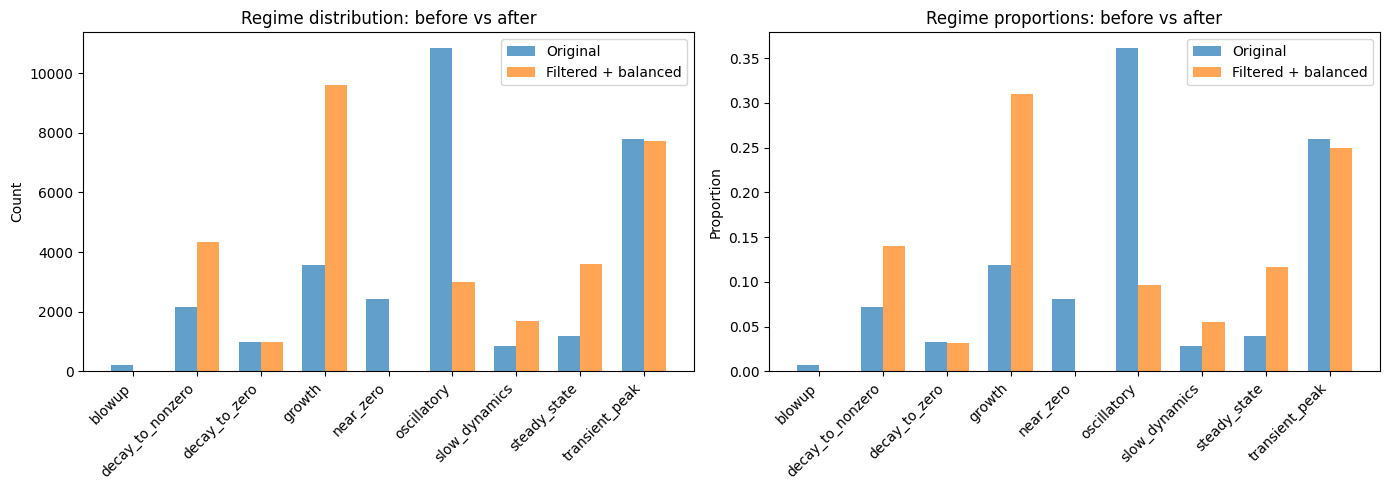

In [7]:
filtered_classifications = [classify_item(item) for item in train_filtered]
filtered_labels = [c[1] for c in filtered_classifications]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_before = Counter(train_labels)
labels_after = Counter(filtered_labels)
regimes = sorted(set(list(labels_before.keys()) + list(labels_after.keys())))
x = np.arange(len(regimes))
width = 0.35

counts_before = [labels_before.get(r, 0) for r in regimes]
counts_after = [labels_after.get(r, 0) for r in regimes]

axes[0].bar(x - width/2, counts_before, width, label="Original", alpha=0.7)
axes[0].bar(x + width/2, counts_after, width, label="Filtered + balanced", alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(regimes, rotation=45, ha="right")
axes[0].set_ylabel("Count")
axes[0].set_title("Regime distribution: before vs after")
axes[0].legend()

total_before = sum(counts_before)
total_after = sum(counts_after)
pct_before = [c / total_before for c in counts_before]
pct_after = [c / total_after for c in counts_after]

axes[1].bar(x - width/2, pct_before, width, label="Original", alpha=0.7)
axes[1].bar(x + width/2, pct_after, width, label="Filtered + balanced", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(regimes, rotation=45, ha="right")
axes[1].set_ylabel("Proportion")
axes[1].set_title("Regime proportions: before vs after")
axes[1].legend()

plt.tight_layout()
plt.show()

## Save and log to W&B

Only run this cell once you're happy with the filtering above.

In [8]:
from pathlib import Path
from crn_surrogate.data.dataset import CRNTrajectoryDataset
import wandb

EXPERIMENT_NAME = "mass_action_3s_det"
output_dir = Path("experiments/datasets")
output_dir.mkdir(parents=True, exist_ok=True)

train_path = output_dir / f"{EXPERIMENT_NAME}_train.pt"
val_path = output_dir / f"{EXPERIMENT_NAME}_val.pt"

torch.save(CRNTrajectoryDataset(train_filtered), train_path)
torch.save(CRNTrajectoryDataset(val_filtered), val_path)
print(f"Saved: {train_path} ({len(train_filtered)} items)")
print(f"Saved: {val_path} ({len(val_filtered)} items)")

run = wandb.init(
    project="crn-surrogate",
    group="mass-action-3s",
    job_type="data-curation",
    name=f"{EXPERIMENT_NAME}_curated_data",
)

artifact = wandb.Artifact(
    name=f"{EXPERIMENT_NAME}_dataset",
    type="dataset",
    metadata={
        "n_train": len(train_filtered),
        "n_val": len(val_filtered),
        "source_artifact": ARTIFACT_REF,
        "train_filter_stats": train_filter_stats,
        "val_filter_stats": val_filter_stats,
    },
)
artifact.add_file(str(train_path))
artifact.add_file(str(val_path))
run.log_artifact(artifact)
run.finish()
print(f"Logged W&B artifact: {EXPERIMENT_NAME}_dataset")

Saved: experiments/datasets/mass_action_3s_v7_train.pt (30921 items)
Saved: experiments/datasets/mass_action_3s_v7_val.pt (2692 items)


wandb: Currently logged in as: jan-mikelson (jan-mikelson-independent) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logged W&B artifact: mass_action_3s_v7_dataset
